# PhishGuard AI — Member 3 Pipeline (Malitha, CIT-24-01-0562)
**Models:** Naive Bayes (ML) + CNN (DL) | **Features:** Bag of Words + Word2Vec | **Preprocessing:** spaCy

Run every cell top to bottom. Upload `phishing_email.csv` when prompted in Stage 1.

In [1]:
# Setup — run once
!pip install -q spacy gensim wordcloud
!python -m spacy download en_core_web_sm -q
import pandas as pd, numpy as np, re, string, pickle, time
import matplotlib.pyplot as plt
import spacy
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              roc_curve, classification_report, ConfusionMatrixDisplay)
from gensim.models import Word2Vec
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint

import os
os.makedirs('models', exist_ok=True)
os.makedirs('screenshots', exist_ok=True)
print("Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 48.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 66.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Setup complete.


## Stage 1 — Data Collection

In [2]:
from google.colab import files
uploaded = files.upload()  # upload phishing_email.csv here

Saving phishing_email.csv to phishing_email.csv


In [3]:
df = pd.read_csv('phishing_email.csv')
df = df.dropna(subset=['text_combined', 'label']).reset_index(drop=True)

print("Dataset shape:", df.shape)
print()
print("Class counts:")
print(df['label'].value_counts())
print()
print("Class balance (%):")
print(df['label'].value_counts(normalize=True) * 100)
print()
print("Sample legitimate email (label=0):")
print(df[df.label==0]['text_combined'].iloc[0][:300])
print()
print("Sample phishing email (label=1):")
print(df[df.label==1]['text_combined'].iloc[0][:300])

Dataset shape: (82486, 2)

Class counts:
label
1    42891
0    39595
Name: count, dtype: int64

Class balance (%):
label
1    51.997915
0    48.002085
Name: proportion, dtype: float64

Sample legitimate email (label=0):
hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls

Sample phishing email (label=1):
link dwl g 510 802 11 g wireless pci lan adapter 39 85 39 85 dwl g 510 high speed 2 4 ghz 802 11 g wireless pci lan adapter ieee 802 11 g standardupto 54 mbpsoperating frequency range 2 4 ghz ideal solution enabling wireless networking capabilities desktops pcs home office dwl g 510 visit http www c


**Talking point for video (Stage 1):** *"My dataset has 82,486 emails combined from six benchmark corpora — Enron, Nigerian Fraud, Ling, Nazario, SpamAssassin, CEAS-08 — with roughly 52% phishing and 48% legitimate, so it's a near-balanced binary classification problem."*

## Stage 2 — Preprocessing (spaCy)

In [5]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
nlp.max_length = 4000000  # Increase max_length for very long texts

def basic_clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)      # remove URLs
    text = re.sub(r'\S+@\S+', ' ', text)               # remove emails
    text = re.sub(r'[^a-z\s]', ' ', text)               # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Cleaning text...")
df['pre_cleaned'] = df['text_combined'].apply(basic_clean)

def spacy_preprocess(texts, batch_size=200):
    cleaned = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        tokens = [tok.lemma_ for tok in doc if not tok.is_stop and not tok.is_punct and len(tok.text) > 2]
        cleaned.append(' '.join(tokens))
    return cleaned

start = time.time()
df['cleaned_text'] = spacy_preprocess(df['pre_cleaned'].tolist())
print(f"Preprocessing done in {(time.time()-start)/60:.1f} minutes")

df = df[df['cleaned_text'].str.strip() != ''].reset_index(drop=True)
df[['text_combined','cleaned_text','label']].head()

Cleaning text...
Preprocessing done in 16.1 minutes


,text_combined,cleaned_text,label
0,hpl nom may 25 2001 see attached file hplno 52...,hpl nom attach file hplno xls hplno xls,0
1,nom actual vols 24 th forwarded sabrae zajac h...,nom actual vol forward sabrae zajac hou ect en...,0
2,enron actuals march 30 april 1 201 estimated a...,enron actual march april estimate actual march...,0
3,hpl nom may 30 2001 see attached file hplno 53...,hpl nom attach file hplno xls hplno xls,0
4,hpl nom june 1 2001 see attached file hplno 60...,hpl nom june attach file hplno xls hplno xls,0


> **If this cell is too slow on Colab CPU (82k rows can take 10-20+ min):** you can subsample for the video demo with `df = df.sample(15000, random_state=42).reset_index(drop=True)` right after loading the CSV in Stage 1, then re-run. Mention in your video that you're demoing on a sample for time, but the pipeline runs on the full 82,486-email set.

**Talking point for video (Stage 2):** *"I built my own preprocessing function using spaCy — lowercasing, removing URLs and emails, punctuation removal, tokenization, stopword removal, and lemmatization — and applied it to the full dataset to produce a cleaned_text column."*

## Stage 3 — EDA (Word Cloud + Length Distribution)

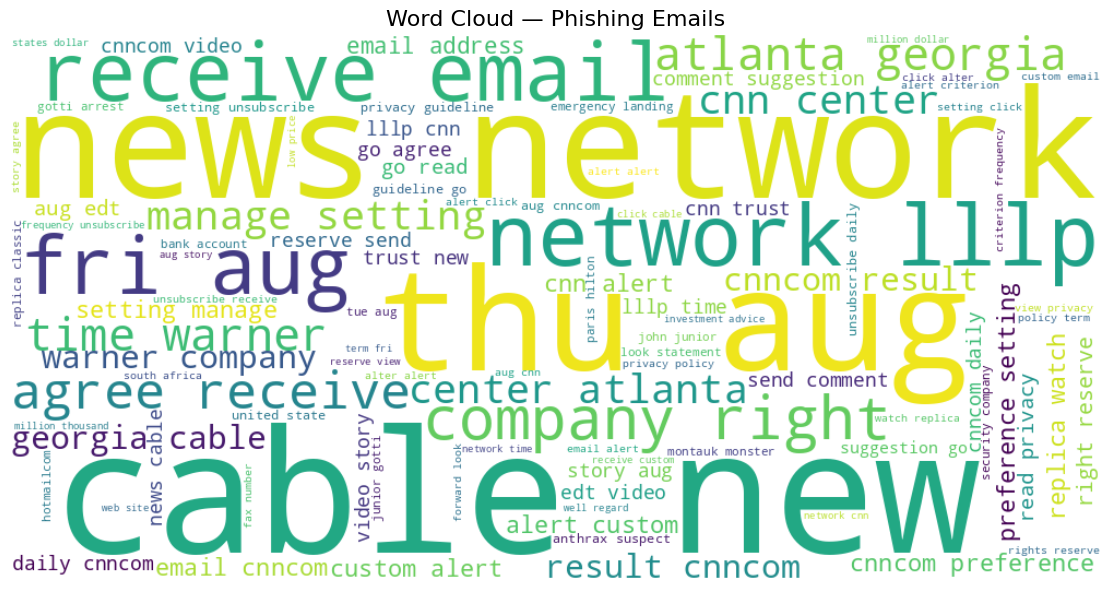

In [6]:
# Word cloud for phishing emails
phishing_text = ' '.join(df[df.label==1]['cleaned_text'].tolist())
wc = WordCloud(width=1000, height=500, background_color='white', max_words=100).generate(phishing_text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Phishing Emails', fontsize=16)
plt.tight_layout()
plt.savefig('screenshots/m3_wordcloud.png', dpi=150)
plt.show()

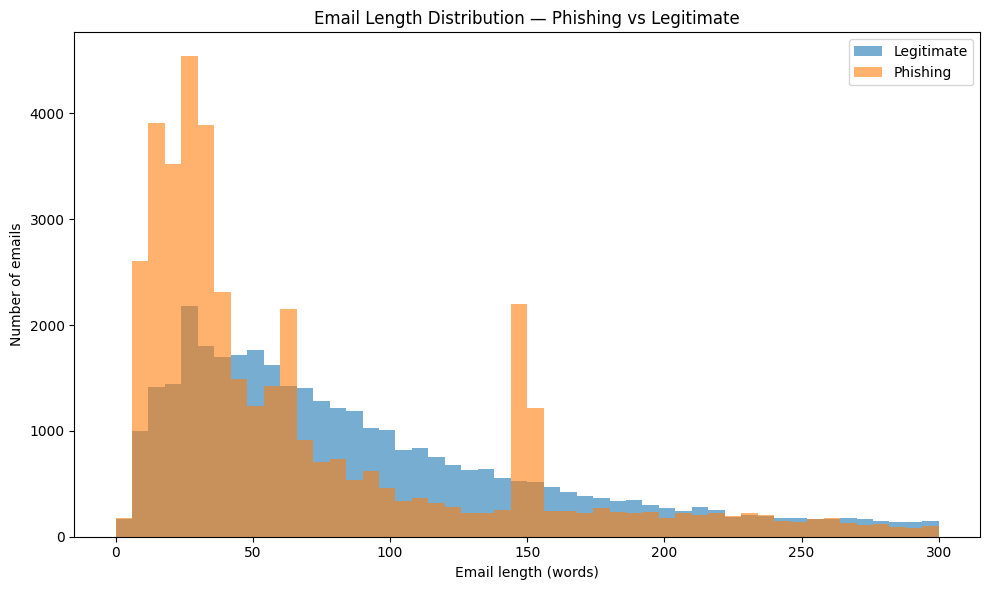

In [7]:
# Email length distribution (word count), phishing vs legitimate
df['word_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,6))
plt.hist(df[df.label==0]['word_count'], bins=50, alpha=0.6, label='Legitimate', range=(0,300))
plt.hist(df[df.label==1]['word_count'], bins=50, alpha=0.6, label='Phishing', range=(0,300))
plt.xlabel('Email length (words)')
plt.ylabel('Number of emails')
plt.title('Email Length Distribution — Phishing vs Legitimate')
plt.legend()
plt.tight_layout()
plt.savefig('screenshots/m3_length_dist.png', dpi=150)
plt.show()

**Talking point for video (Stage 3):** *"My EDA shows the word cloud highlights terms like 'account', 'click', 'verify', 'urgent' dominating phishing emails, and the length distribution shows phishing emails tend to be [shorter/longer/similar] on average compared to legitimate ones."*

## Stage 4 — Feature Engineering (Bag of Words + Word2Vec) + Train/Test Split

In [8]:
X = df['cleaned_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

# --- Bag of Words (used for Naive Bayes) ---
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)
print("BoW matrix shape:", X_train_bow.shape)

with open('models/bow_vectorizer.pkl', 'wb') as f:
    pickle.dump(bow_vectorizer, f)

Train size: 65986  Test size: 16497
BoW matrix shape: (65986, 5000)


In [9]:
# --- Word2Vec (trained on training data, for reference / report) ---
tokenized_train = [t.split() for t in X_train]
w2v_model = Word2Vec(sentences=tokenized_train, vector_size=100, window=5, min_count=2, workers=4, epochs=10)
w2v_model.save('models/word2vec.model')
print("Word2Vec vocab size:", len(w2v_model.wv.index_to_key))
print("Words most similar to 'verify':", w2v_model.wv.most_similar('verify', topn=5) if 'verify' in w2v_model.wv else "not in vocab")

Word2Vec vocab size: 191276
Words most similar to 'verify': [('verification', 0.6256965398788452), ('validate', 0.6108767986297607), ('login', 0.6053524017333984), ('reconfirm', 0.5651977062225342), ('confirm', 0.5322647094726562)]


**Talking point for video (Stage 4):** *"I applied Bag of Words with CountVectorizer for my Naive Bayes model, and trained a Word2Vec model on the training data to capture semantic word relationships, then split the data 80/20 into train and test sets."*

## Stage 5a — ML Model: Naive Bayes

In [10]:
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)
nb_pred = nb_model.predict(X_test_bow)
nb_proba = nb_model.predict_proba(X_test_bow)[:,1]

print("=== Multinomial Naive Bayes ===")
print(classification_report(y_test, nb_pred, target_names=['Legitimate','Phishing']))

# Try ComplementNB as an alternative
cnb_model = ComplementNB()
cnb_model.fit(X_train_bow, y_train)
cnb_pred = cnb_model.predict(X_test_bow)
print("=== Complement Naive Bayes ===")
print(classification_report(y_test, cnb_pred, target_names=['Legitimate','Phishing']))

=== Multinomial Naive Bayes ===
              precision    recall  f1-score   support

  Legitimate       0.94      0.97      0.96      7919
    Phishing       0.97      0.94      0.96      8578

    accuracy                           0.96     16497
   macro avg       0.96      0.96      0.96     16497
weighted avg       0.96      0.96      0.96     16497

=== Complement Naive Bayes ===
              precision    recall  f1-score   support

  Legitimate       0.94      0.97      0.96      7919
    Phishing       0.97      0.94      0.96      8578

    accuracy                           0.96     16497
   macro avg       0.96      0.96      0.96     16497
weighted avg       0.96      0.96      0.96     16497



In [11]:
# Pick the best (usually Multinomial or Complement — compare F1)
nb_f1 = f1_score(y_test, nb_pred)
cnb_f1 = f1_score(y_test, cnb_pred)
best_nb = nb_model if nb_f1 >= cnb_f1 else cnb_model
best_pred = nb_pred if nb_f1 >= cnb_f1 else cnb_pred
best_proba = nb_proba if nb_f1 >= cnb_f1 else cnb_model.predict_proba(X_test_bow)[:,1]
best_name = "MultinomialNB" if nb_f1 >= cnb_f1 else "ComplementNB"
print(f"Best variant: {best_name} (F1={max(nb_f1,cnb_f1):.4f})")

with open('models/nb_model.pkl', 'wb') as f:
    pickle.dump(best_nb, f)

Best variant: MultinomialNB (F1=0.9585)


Accuracy:  0.9575
Precision: 0.9728
Recall:    0.9447
F1-score:  0.9585
ROC-AUC:   0.9875


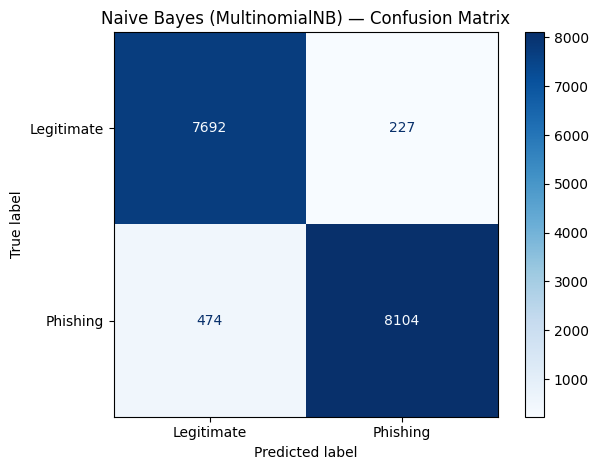

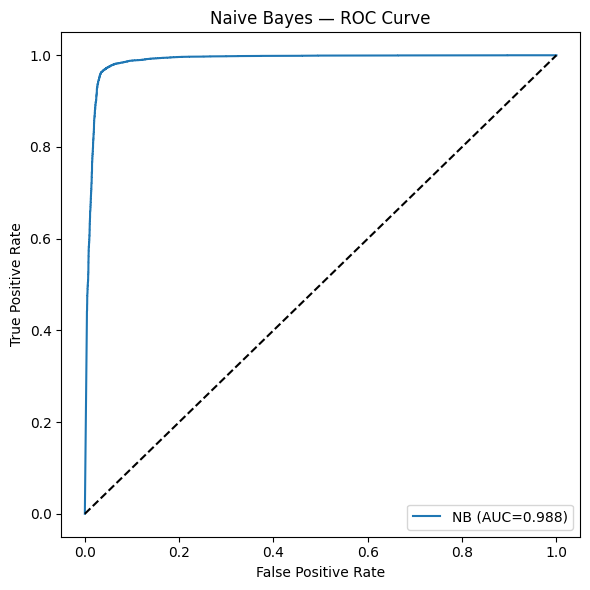

In [12]:
# Naive Bayes final metrics
nb_accuracy  = accuracy_score(y_test, best_pred)
nb_precision = precision_score(y_test, best_pred)
nb_recall    = recall_score(y_test, best_pred)
nb_f1_final  = f1_score(y_test, best_pred)
nb_roc_auc   = roc_auc_score(y_test, best_proba)

print(f"Accuracy:  {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall:    {nb_recall:.4f}")
print(f"F1-score:  {nb_f1_final:.4f}")
print(f"ROC-AUC:   {nb_roc_auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate','Phishing'])
disp.plot(cmap='Blues')
plt.title(f'Naive Bayes ({best_name}) — Confusion Matrix')
plt.tight_layout()
plt.savefig('screenshots/m3_nb_cm.png', dpi=150)
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, best_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'NB (AUC={nb_roc_auc:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Naive Bayes — ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('screenshots/m3_nb_roc.png', dpi=150)
plt.show()

**Talking point for video (NB):** *"My Naive Bayes model achieved an F1 of [X] and ROC-AUC of [X]. I chose it because it's fast to train and works well with Bag of Words features for catching keyword-based phishing patterns like 'verify' and 'urgent'."*

## Stage 5b — DL Model: CNN

In [13]:
MAX_WORDS = 10000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print("Padded train shape:", X_train_pad.shape)

with open('models/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

Padded train shape: (65986, 200)


In [14]:
cnn_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
checkpoint = ModelCheckpoint('models/cnn_model.keras', monitor='val_accuracy',
                              save_best_only=True, verbose=1)

history = cnn_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=[checkpoint]
)

Epoch 1/10
928/928 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9225 - loss: 0.1945
Epoch 1: val_accuracy improved from None to 0.98682, saving model to models/cnn_model.keras

Epoch 1: finished saving model to models/cnn_model.keras
928/928 ━━━━━━━━━━━━━━━━━━━━ 171s 181ms/step - accuracy: 0.9656 - loss: 0.0944 - val_accuracy: 0.9868 - val_loss: 0.0398
Epoch 2/10
928/928 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9948 - loss: 0.0174
Epoch 2: val_accuracy improved from 0.98682 to 0.98757, saving model to models/cnn_model.keras

Epoch 2: finished saving model to models/cnn_model.keras
928/928 ━━━━━━━━━━━━━━━━━━━━ 174s 188ms/step - accuracy: 0.9939 - loss: 0.0192 - val_accuracy: 0.9876 - val_loss: 0.0427
Epoch 3/10
928/928 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9983 - loss: 0.0059
Epoch 3: val_accuracy improved from 0.98757 to 0.98939, saving model to models/cnn_model.keras

Epoch 3: finished saving model to models/cnn_model.keras
928/928 ━━━━━━━━━━━━━━━━━━━━ 166s 179m

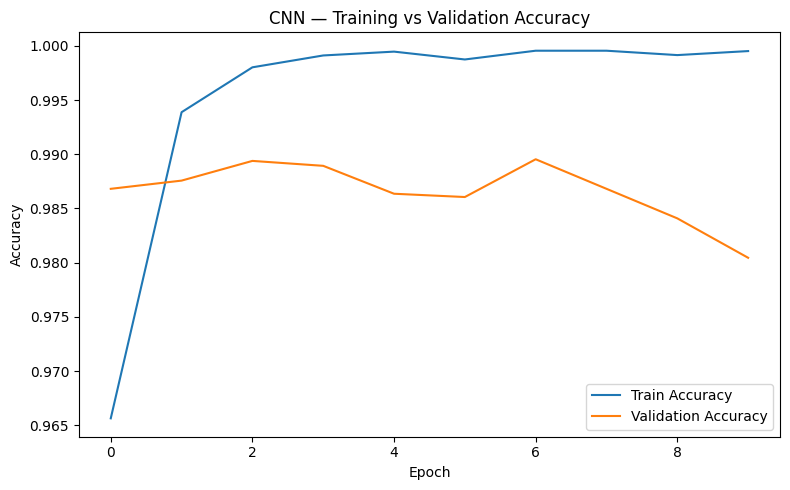

In [16]:
# Training curves
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('CNN — Training vs Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('screenshots/m3_cnn_training.png', dpi=150)
plt.show()

516/516 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step
Accuracy:  0.9863
Precision: 0.9838
Recall:    0.9900
F1-score:  0.9869
ROC-AUC:   0.9991


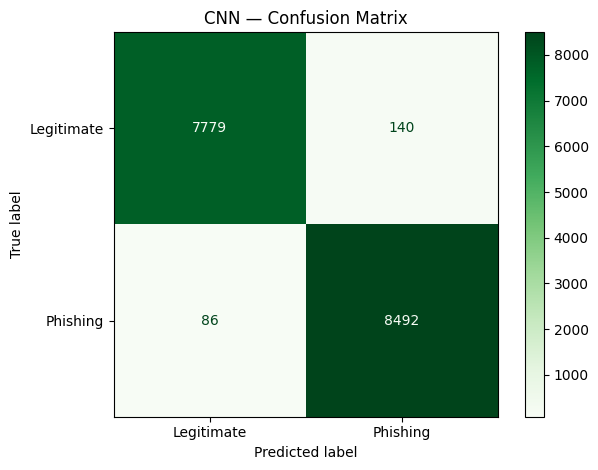

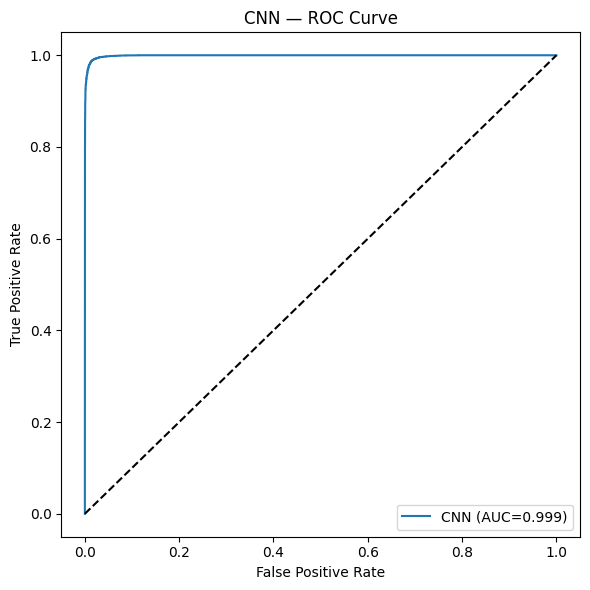

In [17]:
best_cnn = load_model('models/cnn_model.keras')

cnn_proba = best_cnn.predict(X_test_pad).ravel()
cnn_pred = (cnn_proba >= 0.5).astype(int)

cnn_accuracy  = accuracy_score(y_test, cnn_pred)
cnn_precision = precision_score(y_test, cnn_pred)
cnn_recall    = recall_score(y_test, cnn_pred)
cnn_f1        = f1_score(y_test, cnn_pred)
cnn_roc_auc   = roc_auc_score(y_test, cnn_proba)

print(f"Accuracy:  {cnn_accuracy:.4f}")
print(f"Precision: {cnn_precision:.4f}")
print(f"Recall:    {cnn_recall:.4f}")
print(f"F1-score:  {cnn_f1:.4f}")
print(f"ROC-AUC:   {cnn_roc_auc:.4f}")

cm2 = confusion_matrix(y_test, cnn_pred)
disp2 = ConfusionMatrixDisplay(cm2, display_labels=['Legitimate','Phishing'])
disp2.plot(cmap='Greens')
plt.title('CNN — Confusion Matrix')
plt.tight_layout()
plt.savefig('screenshots/m3_cnn_cm.png', dpi=150)
plt.show()

fpr2, tpr2, _ = roc_curve(y_test, cnn_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr2, tpr2, label=f'CNN (AUC={cnn_roc_auc:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('CNN — ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('screenshots/m3_cnn_roc.png', dpi=150)
plt.show()

**Talking point for video (CNN):** *"CNN stands for Convolutional Neural Network. The Conv1D layer slides a filter across word sequences to detect local patterns like 'click here immediately', GlobalMaxPooling picks the strongest signal, and the Dense layers make the final call. My CNN achieved an F1 of [X] and ROC-AUC of [X]."*

## Stage 6 — Final Results Table (send this to Shakkya)

In [18]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'CNN'],
    'Accuracy': [nb_accuracy, cnn_accuracy],
    'Precision': [nb_precision, cnn_precision],
    'Recall': [nb_recall, cnn_recall],
    'F1': [nb_f1_final, cnn_f1],
    'ROC-AUC': [nb_roc_auc, cnn_roc_auc]
})
print(results.to_string(index=False))
results.to_csv('models/member3_results.csv', index=False)

      Model  Accuracy  Precision   Recall       F1  ROC-AUC
Naive Bayes  0.957507   0.972752 0.944742 0.958543 0.987510
        CNN  0.986301   0.983781 0.989974 0.986868 0.999121


In [19]:
# Zip everything so you can download models + screenshots in one go
import shutil
shutil.make_archive('member3_outputs', 'zip', '.', base_dir='models')
shutil.make_archive('member3_screenshots', 'zip', '.', base_dir='screenshots')

from google.colab import files
files.download('member3_outputs.zip')
files.download('member3_screenshots.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Next: Git commit
Download the zips above, extract into your local repo's `models/` and `screenshots/` folders, then:

```bash
git checkout feature/malitha_CIT-24-01-0562
git add models/ screenshots/
git commit -m "Naive Bayes tuned and CNN training complete — final scores recorded, ROC curves and confusion matrices saved"
git push
```
Then record your video segment showing this notebook running + your results + a scroll through your commit history.